In [ ]:
# --------------------------------------------------
# Robust Installation and Library Loading
# --------------------------------------------------

# Add your personal library folder as the first path
.libPaths(c("~/R/libs", .libPaths()))

# Print library paths to verify that ~/R/libs is included
print(.libPaths())
library(dplyr)


# Helper function to check for and install packages if missing
check_install <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, dependencies = TRUE)
  }
}

# Set CRAN mirror for consistency
options(repos = c(CRAN = "https://cloud.r-project.org"))

# Ensure ggplot2 is installed and load it (for plotting)
check_install("ggplot2")
library(ggplot2)

# Ensure calinf is installed and load it (for distributional_seed & drnorm)
if (!requireNamespace("calinf", quietly = TRUE)) {
  # Install devtools if not installed yet
  if (!requireNamespace("devtools", quietly = TRUE)) {
    install.packages("devtools", dependencies = TRUE)
  }
  library(devtools)
  install_github("rothenhaeusler/calinf")
}
library(calinf)

# Attempt to load dplyr and tibble; if unavailable, fall back to base R for data combination
use_dplyr <- FALSE
if(requireNamespace("dplyr", quietly = TRUE) && requireNamespace("tibble", quietly = TRUE)) {
  use_dplyr <- TRUE
  library(dplyr)
  library(tibble)
}


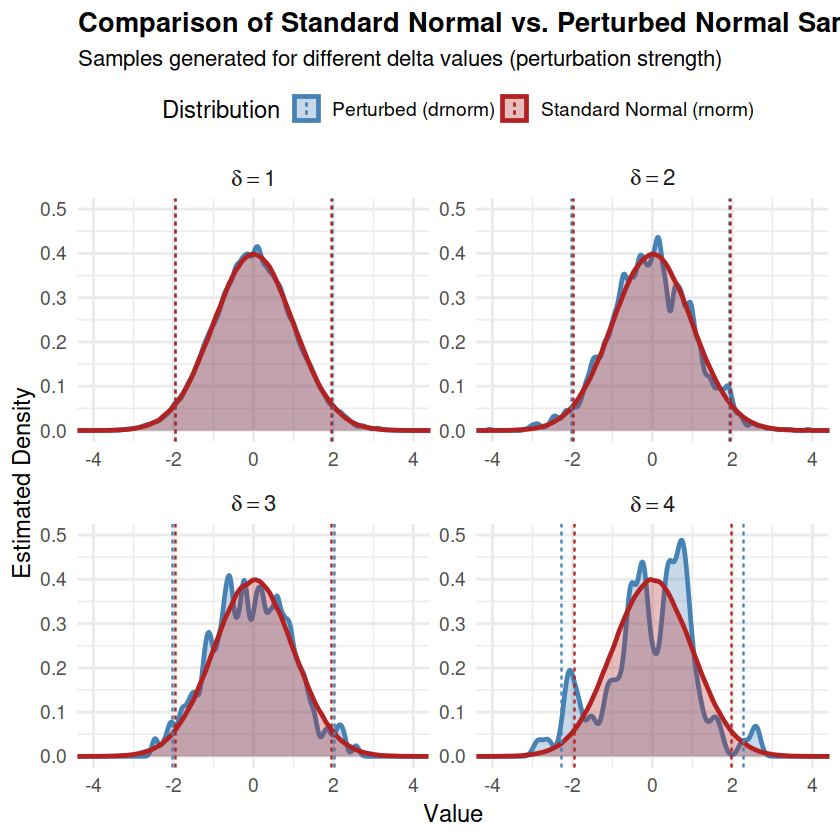

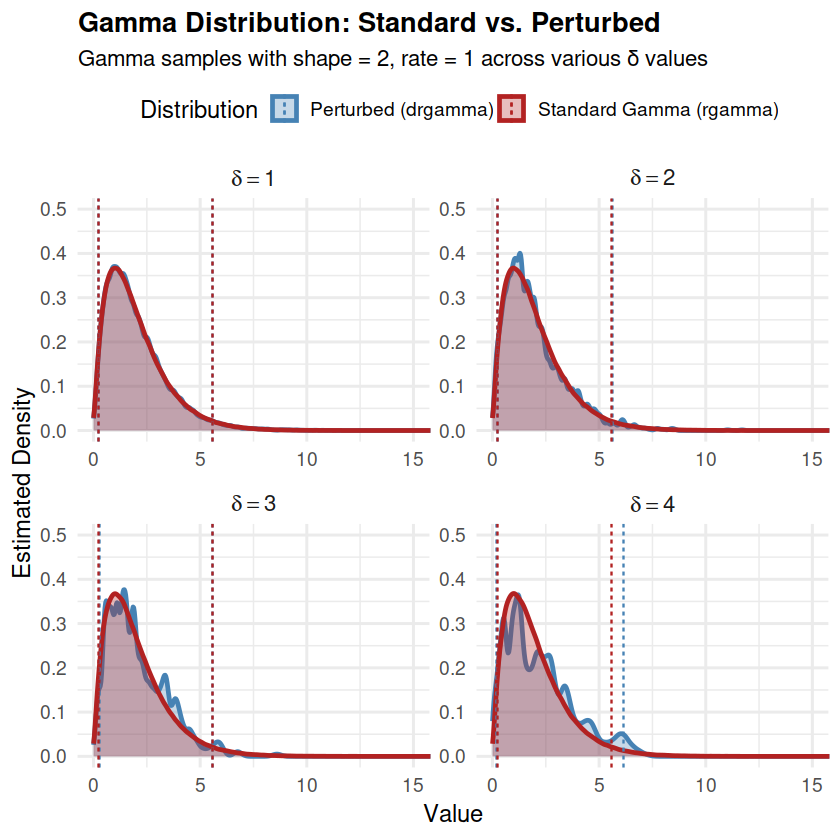

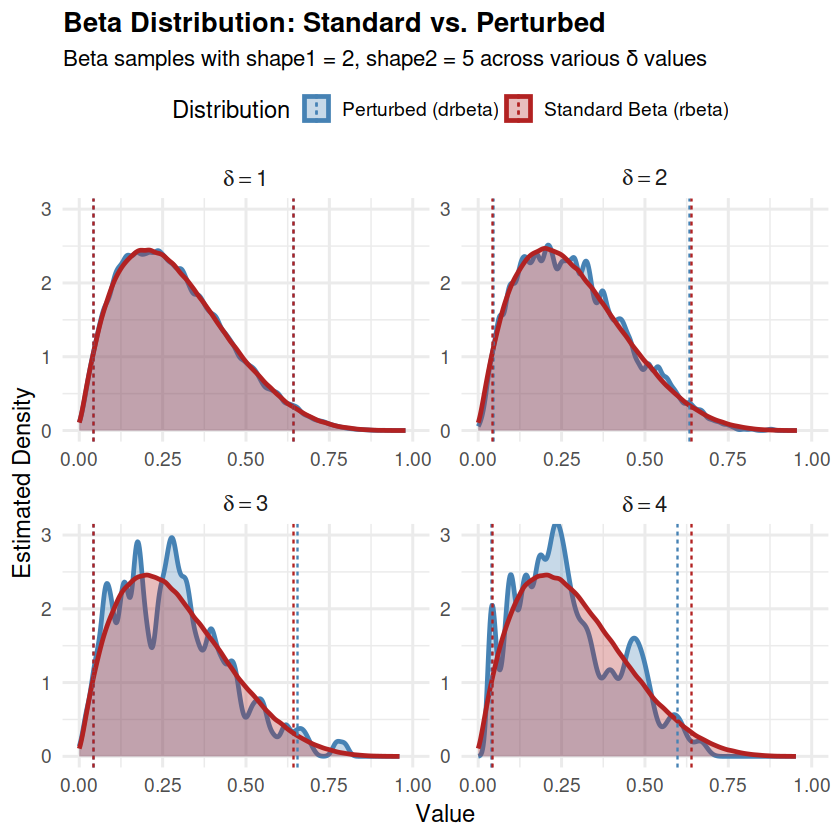

In [6]:
# --------------------------------------------------
# Sampling: Generate 1e6 Samples for Each delta Value (Normal)
# --------------------------------------------------
set.seed(123)  # For reproducibility

n <- 1e6  # Number of samples per distribution per delta
deltas <- c(5, 20, 50, 100)  # Different delta values

# List to store data frames for each delta
df_list <- list()

for (delta in deltas) {
  # Generate perturbed samples using drnorm from calinf
  d_seed <- distributional_seed(n, delta)
  sample_perturbed <- drnorm(d_seed)
  
  # Generate corresponding standard normal samples
  sample_standard <- rnorm(n)
  
  # Create a data frame for current delta. Add a column 'delta' and a 'type' to identify the distribution.
  if (use_dplyr) {
    df_delta <- bind_rows(
      tibble(value = sample_perturbed, type = "Perturbed (drnorm)", delta = as.factor(delta)),
      tibble(value = sample_standard, type = "Standard Normal (rnorm)", delta = as.factor(delta))
    )
  } else {
    df_delta <- data.frame(
      value = c(sample_perturbed, sample_standard),
      type = rep(c("Perturbed (drnorm)", "Standard Normal (rnorm)"), each = n),
      delta = factor(rep(delta, 2 * n)),
      stringsAsFactors = FALSE
    )
  }
  
  # Append the data frame for current delta to the list
  df_list[[as.character(delta)]] <- df_delta
  
  # Clean up variables to free memory
  rm(d_seed, sample_perturbed, sample_standard)
}

# Combine all data frames. Use dplyr if available.
if (use_dplyr) {
  df_all <- bind_rows(df_list)
} else {
  df_all <- do.call(rbind, df_list)
}

# Compute the 2.5th and 97.5th percentiles for each group in the Normal case
if (use_dplyr) {
  quantiles_norm <- df_all %>%
    group_by(delta, type) %>%
    summarize(q025 = quantile(value, 0.025),
              q975 = quantile(value, 0.975),
              .groups = "drop")
} else {
  quantiles_norm <- do.call(rbind, lapply(split(df_all, list(df_all$delta, df_all$type)), 
    function(d) {
      qs <- quantile(d$value, probs = c(0.025, 0.975))
      data.frame(delta = unique(d$delta), type = unique(d$type), q025 = qs[1], q975 = qs[2])
    }))
}

# Plotting: Compare Densities for Normal (with vertical quantile lines)
p <- ggplot(df_all, aes(x = value, fill = type, color = type)) +
  geom_density(alpha = 0.3, size = 1) +
  # Add vertical dashed lines at the 2.5th and 97.5th percentiles
  geom_vline(data = quantiles_norm, aes(xintercept = q025, color = type),
             linetype = "dashed", size = 0.5) +
  geom_vline(data = quantiles_norm, aes(xintercept = q975, color = type),
             linetype = "dashed", size = 0.5) +
  facet_wrap(~ delta, ncol = 2, scales = "free",
             labeller = label_bquote(delta == .(delta))) +
  # Use coord_cartesian to set visible axis limits without dropping data points.
  coord_cartesian(xlim = c(-4, 4), ylim = c(0, 0.5)) +
  scale_fill_manual(values = c("steelblue", "firebrick")) +
  scale_color_manual(values = c("steelblue", "firebrick")) +
  labs(
    title = "Comparison of Standard Normal vs. Perturbed Normal Samples",
    subtitle = "Samples generated for different delta values (perturbation strength)",
    x = "Value",
    y = "Estimated Density",
    fill = "Distribution",
    color = "Distribution"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 13),
    legend.position = "top",
    strip.text = element_text(face = "bold", size = 13)
  )
print(p)

# --------------------------------------------------
# Gamma Distribution Sampling and Plotting
# --------------------------------------------------
# We use shape = 2, rate = 1 for gamma.
df_list_gamma <- list()  # List to store gamma data frames

for (delta in deltas) {
  # Generate perturbed gamma samples using drgamma (calinf)
  d_seed <- distributional_seed(n, delta)
  sample_perturbed <- drgamma(d_seed, shape = 2, rate = 1)
  
  # Generate corresponding standard gamma samples using rgamma
  sample_standard <- rgamma(n, shape = 2, rate = 1)
  
  # Create a data frame for the current delta
  if (use_dplyr) {
    df_delta <- bind_rows(
      tibble(value = sample_perturbed, type = "Perturbed (drgamma)", delta = as.factor(delta)),
      tibble(value = sample_standard,  type = "Standard Gamma (rgamma)", delta = as.factor(delta))
    )
  } else {
    df_delta <- data.frame(
      value = c(sample_perturbed, sample_standard),
      type = rep(c("Perturbed (drgamma)", "Standard Gamma (rgamma)"), each = n),
      delta = factor(rep(delta, 2 * n)),
      stringsAsFactors = FALSE
    )
  }
  
  df_list_gamma[[as.character(delta)]] <- df_delta
  
  # Free memory for next iteration
  rm(d_seed, sample_perturbed, sample_standard)
}

# Combine all gamma data frames
if (use_dplyr) {
  df_gamma <- bind_rows(df_list_gamma)
} else {
  df_gamma <- do.call(rbind, df_list_gamma)
}

# Compute quantiles for the Gamma data
if (use_dplyr) {
  quantiles_gamma <- df_gamma %>%
    group_by(delta, type) %>%
    summarize(q025 = quantile(value, 0.025),
              q975 = quantile(value, 0.975),
              .groups = "drop")
} else {
  quantiles_gamma <- do.call(rbind, lapply(split(df_gamma, list(df_gamma$delta, df_gamma$type)), 
    function(d) {
      qs <- quantile(d$value, probs = c(0.025, 0.975))
      data.frame(delta = unique(d$delta), type = unique(d$type), q025 = qs[1], q975 = qs[2])
    }))
}

# Create the gamma density plot with quantile lines using coord_cartesian
p_gamma <- ggplot(df_gamma, aes(x = value, fill = type, color = type)) +
  geom_density(alpha = 0.3, size = 1) +
  geom_vline(data = quantiles_gamma, aes(xintercept = q025, color = type),
             linetype = "dashed", size = 0.5) +
  geom_vline(data = quantiles_gamma, aes(xintercept = q975, color = type),
             linetype = "dashed", size = 0.5) +
  facet_wrap(~ delta, ncol = 2, scales = "free",
             labeller = label_bquote(delta == .(delta))) +
  coord_cartesian(xlim = c(0, 15), ylim = c(0, 0.5)) +
  scale_fill_manual(values = c("steelblue", "firebrick")) +
  scale_color_manual(values = c("steelblue", "firebrick")) +
  labs(
    title = "Gamma Distribution: Standard vs. Perturbed",
    subtitle = "Gamma samples with shape = 2, rate = 1 across various δ values",
    x = "Value",
    y = "Estimated Density",
    fill = "Distribution",
    color = "Distribution"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 13),
    legend.position = "top",
    strip.text = element_text(face = "bold", size = 13)
  )
print(p_gamma)

# --------------------------------------------------
# Beta Distribution Sampling and Plotting
# --------------------------------------------------
# We use shape1 = 2 and shape2 = 5 for beta.
df_list_beta <- list()  # List to store beta data frames

for (delta in deltas) {
  # Generate perturbed beta samples using drbeta (calinf)
  d_seed <- distributional_seed(n, delta)
  sample_perturbed <- drbeta(d_seed, shape1 = 2, shape2 = 5)
  
  # Generate corresponding standard beta samples using rbeta
  sample_standard <- rbeta(n, shape1 = 2, shape2 = 5)
  
  # Create a data frame for the current delta value
  if (use_dplyr) {
    df_delta <- bind_rows(
      tibble(value = sample_perturbed, type = "Perturbed (drbeta)", delta = as.factor(delta)),
      tibble(value = sample_standard,  type = "Standard Beta (rbeta)", delta = as.factor(delta))
    )
  } else {
    df_delta <- data.frame(
      value = c(sample_perturbed, sample_standard),
      type = rep(c("Perturbed (drbeta)", "Standard Beta (rbeta)"), each = n),
      delta = factor(rep(delta, 2 * n)),
      stringsAsFactors = FALSE
    )
  }
  
  df_list_beta[[as.character(delta)]] <- df_delta
  
  # Free memory
  rm(d_seed, sample_perturbed, sample_standard)
}

# Combine all beta data frames
if (use_dplyr) {
  df_beta <- bind_rows(df_list_beta)
} else {
  df_beta <- do.call(rbind, df_list_beta)
}

# Compute quantiles for the Beta data
if (use_dplyr) {
  quantiles_beta <- df_beta %>%
    group_by(delta, type) %>%
    summarize(q025 = quantile(value, 0.025),
              q975 = quantile(value, 0.975),
              .groups = "drop")
} else {
  quantiles_beta <- do.call(rbind, lapply(split(df_beta, list(df_beta$delta, df_beta$type)), 
    function(d) {
      qs <- quantile(d$value, probs = c(0.025, 0.975))
      data.frame(delta = unique(d$delta), type = unique(d$type), q025 = qs[1], q975 = qs[2])
    }))
}

# Create the beta density plot with quantile lines using coord_cartesian
p_beta <- ggplot(df_beta, aes(x = value, fill = type, color = type)) +
  geom_density(alpha = 0.3, size = 1) +
  geom_vline(data = quantiles_beta, aes(xintercept = q025, color = type),
             linetype = "dashed", size = 0.5) +
  geom_vline(data = quantiles_beta, aes(xintercept = q975, color = type),
             linetype = "dashed", size = 0.5) +
  facet_wrap(~ delta, ncol = 2, scales = "free",
             labeller = label_bquote(delta == .(delta))) +
  coord_cartesian(xlim = c(0, 1), ylim = c(0, 3)) +
  scale_fill_manual(values = c("steelblue", "firebrick")) +
  scale_color_manual(values = c("steelblue", "firebrick")) +
  labs(
    title = "Beta Distribution: Standard vs. Perturbed",
    subtitle = "Beta samples with shape1 = 2, shape2 = 5 across various δ values",
    x = "Value",
    y = "Estimated Density",
    fill = "Distribution",
    color = "Distribution"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 13),
    legend.position = "top",
    strip.text = element_text(face = "bold", size = 13)
  )
print(p_beta)
